In [25]:
import os


os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["JAX_ENABLE_X64"] = "true"

from functools import partial

import numpy as onp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from msmjax.benchmark_tools import path_input_structures
from msmjax.convenience import suggest_msm_params, set_up_grids_and_kernels
from msmjax.shortrange import make_pair_term_fn, make_compute_U0
from msmjax.flexcell import make_flex_cell_U1plus_fn

# Load structure

In [5]:
structures = onp.load(path_input_structures / "structures_1000.npz")

i_structure = 0
pos = structures["positions"][i_structure].astype(onp.float64)
chg = structures["charges"][i_structure].astype(onp.float64)
cell = structures["cells"][i_structure].astype(onp.float64)

box_lengths = onp.diag(cell)
n_structures = len(structures["positions"])
n_particles = pos.shape[0]
avg_particle_spacing = (onp.linalg.det(cell) / n_particles) ** (1 / 3)

# Define energy calculators

In [45]:
calc_energy_ref_nonperiodic = make_pair_term_fn(
    kernel_fn=lambda x: 1.0 / x, pbc=(False, False, False)
)
calc_energy_ref_nonperiodic = jax.jit(
    partial(calc_energy_ref_nonperiodic, cell=cell)
)

In [46]:
def set_up_flex_cell_msm_energy_fn(reference_cell, pbc, **msm_params):
    kernel_fns, _, _ = set_up_grids_and_kernels(
        box_lengths=box_lengths, pbcs=pbc, **msm_params
    )
    calc_U0 = make_compute_U0(kernel_fns=kernel_fns, pbc=pbc)
    calc_U1plus = make_flex_cell_U1plus_fn(
        kernel_fns=kernel_fns,
        pbc=pbc,
        reference_cell=reference_cell,
        **msm_params,
    )

    @jax.jit  # TODO: jit here or later?
    def calc_energy(positions, charges, cell):
        return calc_U0(positions, charges, cell) + calc_U1plus(
            positions, charges, cell
        )

    return calc_energy

# Orthogonal: Isotropic strain

In [47]:
lower = 0.5
upper = 2.0
stepsize = 0.05
n_steps = int(onp.round((1.4 - 0.6) / 0.05))
all_deformations = onp.linspace(lower, upper, n_steps)

In [50]:
PBC = (False, False, False)

R_CUT = 3.5
SPACINGS = [1.0, 0.8, 0.6]

results_msm_flex = {}
for spacing in SPACINGS:
    msm_params = suggest_msm_params(
        box_lengths=box_lengths,
        pbcs=PBC,
        n_particles=n_particles,
        level_one_gridspacing=spacing * avg_particle_spacing,
        level_zero_cutoff=R_CUT * avg_particle_spacing,
    )
    calc_energy_msm = set_up_flex_cell_msm_energy_fn(
        reference_cell=cell, pbc=PBC, **msm_params
    )

    @jax.jit
    def calc_forces_ref(positions, charges):
        return -jax.grad(calc_energy_ref_nonperiodic)(positions, charges)

    @jax.jit
    def calc_forces_msm(positions, charges, cell):
        return -jax.grad(calc_energy_msm)(positions, charges, cell)

    energies_ref = onp.full_like(all_deformations, onp.nan)
    forces_ref = onp.full((len(all_deformations), n_particles, 3), onp.nan)

    energies_msm_flex = onp.full_like(all_deformations, onp.nan)
    forces_msm_flex = onp.full_like(forces_ref, onp.nan)

    # TODO: ref results don't need to be computed inside this loop

    for i, deformation in enumerate(all_deformations):
        pos_deformed = pos * deformation
        cell_deformed = cell * deformation

        energies_ref[i] = calc_energy_ref_nonperiodic(pos_deformed, chg)
        forces_ref[i] = calc_forces_ref(pos_deformed, chg)

        energies_msm_flex[i] = calc_energy_msm(
            pos_deformed, chg, cell_deformed
        )
        forces_msm_flex[i] = calc_forces_msm(pos_deformed, chg, cell_deformed)

    results_msm_flex[spacing] = {
        "energies_msm_flex": energies_msm_flex,
        "forces_msm_flex": forces_msm_flex,
    }

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Cutoff at highest-but-one level not too large relative to simulation box size ("criterion 2.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Highest-level grid not coarser than simulation box size ("criterion 1.")
*) Cutoff at highest-but-one level not too large relative to simulation box size ("criterion 2.")

Suggested value for max grid level L was found according to criterion/criteria:
(if multiple criteria listed, that means they agree on the suggested L)
*) Cutoff at highest-but-one level not too large relative to simulation box size ("criterion 2.")



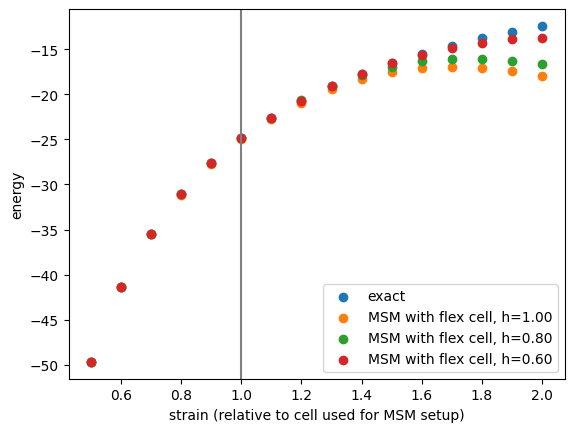

In [51]:
fig, ax = plt.subplots()
# fig.suptitle()    # TODO
ax.set_xlabel("strain (relative to cell used for MSM setup)")
ax.set_ylabel("energy")
ax.scatter(all_deformations, energies_ref, label="exact")
for h, res in results_msm_flex.items():
    # TODO: different label if periodic
    ax.scatter(
        all_deformations,
        res["energies_msm_flex"],
        label=f"MSM with flex cell, h={h:.2f}",
    )
ax.axvline(1.0, color="gray")
ax.legend()
plt.show()

# Orthogonal: Anisotropic strain

# General parallelepipeds